# Waveform Feature Dataset (all sessions, all units)

Build **one big table** that contains, for **every unit of every session**, its
peak-channel waveform, morphology features, brain region, and a **QC label**
(passed default QC or not). Save it once to a single CSV so downstream analysis
(feature exploration, clustering, ...) can just reload the CSV instead of
re-reading the NWBs every time.

Each row contains:

- `session_name` — session-core id
- `unit_index` — within-session unit index
- `region` — CCF brain region (or empty)
- `qc_pass` — `True` if the unit passed default QC, else `False`
- the morphology features (`trough_to_peak_ms`, `half_width_ms`, ...)
- `pre_ms` / `post_ms` / `sampling_rate_hz` — timing context (to rebuild the axis)
- `wf_000 ... wf_NNN` — the raw trough-aligned peak-channel waveform samples

All the reusable logic lives in `waveform_clustering.py`
(`build_features_dataset`, `save_dataset_csv`, `load_features_dataset`), so this
notebook stays thin.

**Workflow**
1. Discover all sessions and build the full per-unit dataset.
2. Save it to a single CSV.
3. **Example** — reload the CSV and run the same feature / clustering /
   visualization workflow as `waveform_clustering.ipynb`.


## 1. Imports & configuration

In [1]:
# =============================================================================
# ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Path to the custom analysis modules (update for your local install).
MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"Analysis modules loaded from: {MODULE_PATH}")

Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.decomposition import PCA

# Project utilities (src/aind_dft_ephys_analysis)
from general_utils import find_ephys_sessions

# Reusable waveform-clustering functions (see waveform_clustering.py)
from waveform_clustering import (
    FEATURE_COLS,
    WAVEFORM_COL_PREFIX,
    build_features_dataset,
    save_dataset_csv,
    load_features_dataset,
    normalize_waveform,
    scale_features,
    estimate_n_clusters,
    cluster_waveforms,
)

%matplotlib inline

# ---- Configuration -------------------------------------------------------
# Waveform sampling rate (Neuropixels standard). Adjust if your probe differs.
SAMPLING_RATE_HZ = 30_000.0

# Fixed window (ms) extracted around each unit's trough so waveforms from
# probes/sessions with different sample counts can be pooled together.
PRE_MS = 1.0
POST_MS = 2.0

# Where to write / read the big dataset CSV.
RESULTS_DIR = Path("/root/capsule/scratch/waveform_clustering")
DATASET_CSV = RESULTS_DIR / "all_sessions_waveform_features.csv"

RANDOM_STATE = 0
feature_cols = FEATURE_COLS

## 2. Build the full per-unit dataset

Loop over every (spike-sorted) session and, for **every** unit that yields a
valid trough-aligned waveform, extract its peak-channel waveform + morphology
features and label whether it passed default QC. This reads each NWB once.

> This step can take a while (it opens every session). Once saved (next
> section) you can skip straight to the reload/example sections.


In [3]:
# Discover all ephys sessions (prefer spike-sorted ones).
all_sessions, sessions_by_animal, spike_sorted_sessions = find_ephys_sessions()
sessions_to_use = spike_sorted_sessions if len(spike_sorted_sessions) else all_sessions
print(f"Found {len(all_sessions)} sessions; using {len(sessions_to_use)} spike-sorted sessions.")

# Build the big table: every unit of every session, QC-labelled, with the raw
# trough-aligned waveform samples (wf_000 ... wf_NNN) stored inline.
dataset = build_features_dataset(
    sessions_to_use,
    pre_ms=PRE_MS,
    post_ms=POST_MS,
    sampling_rate_hz=SAMPLING_RATE_HZ,
    qc_metric_fallback=True,
    normalize=True,          # features computed from normalized waveforms
    include_waveform=True,   # store the per-sample waveform columns
    verbose=True,
)

print(f"\nDataset shape: {dataset.shape[0]} units x {dataset.shape[1]} columns")
dataset.head()

Found 63 sessions; using 55 spike-sorted sessions.
Found ephys NWB: /root/capsule/data/ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25/nwb/ecephys_753124_2024-12-10_17-24-56_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25/nwb/ecephys_753124_2024-12-10_17-24-56_experiment1_recording1.nwb
Number of units passing QC: 528
[1/55] 753124_2024-12-10_17-24-56: +1972 units (528 QC-pass; total 1972)
Found ephys NWB: /root/capsule/data/ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58/nwb/ecephys_753125_2024-10-09_10-50-19_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58/nwb/ecephys_753125_2024-10-09_10-50-19_experiment1_recording1.nwb
Number of units passing QC: 248
[2/55] 753125_2024-10-09_10-50-19: +1382 units (248 QC-pass; total 3354)
Found ephys NWB: /root/capsule/data/ecephys_75312

,session_name,unit_index,region,qc_pass,trough_to_peak_ms,half_width_ms,peak_trough_ratio,pre_peak_ratio,pre_peak_ms,repolarization_slope,...,wf_081,wf_082,wf_083,wf_084,wf_085,wf_086,wf_087,wf_088,wf_089,wf_090
0,753124_2024-12-10_17-24-56,0,None,False,0.933333,0.166667,0.289298,0.281644,0.100000,3.190931,...,2.560543,3.326837,1.915735,2.083946,1.775559,1.065336,-0.093450,0.037380,-1.495208,-1.317651
1,753124_2024-12-10_17-24-56,1,None,False,1.133333,0.200000,0.062465,0.989715,0.133333,5.077676,...,13.630505,11.670750,10.822500,8.880307,9.365845,7.254000,6.610504,5.393702,4.609802,4.089150
2,753124_2024-12-10_17-24-56,2,None,False,0.833333,0.166667,0.314050,0.195557,0.133333,3.533937,...,-0.549899,-1.474199,-1.175852,-1.994850,-3.527547,-3.679649,-3.960453,-3.457349,-4.954951,-4.937402
3,753124_2024-12-10_17-24-56,3,None,False,0.133333,0.066667,0.835618,0.000000,0.766667,17.353904,...,-2.392552,-2.931914,-3.561169,-2.005319,-1.078723,0.760639,-0.421809,0.822874,0.746809,1.382981
4,753124_2024-12-10_17-24-56,4,None,False,0.100000,0.000000,0.190187,0.217410,0.066667,10.515363,...,20.001147,-18.480131,17.409596,-18.099897,15.525897,-18.000456,15.204147,-18.994947,14.420246,-18.275396


In [ ]:
# Quick overview: split QC-passed vs QC-failed units, with per-region and
# per-session tallies for each group.
qc_pass = dataset["qc_pass"].astype(bool)
passed = dataset[qc_pass]
failed = dataset[~qc_pass]

print("QC label counts:")
print(f"  passed:     {len(passed)}")
print(f"  not passed: {len(failed)}")
print(f"  total:      {len(dataset)}\n")

print("Units per region (top 20) - QC PASSED:")
print(passed["region"].fillna("None").value_counts().head(20), "\n")

print("Units per region (top 20) - NOT PASSED:")
print(failed["region"].fillna("None").value_counts().head(20), "\n")

print(f"Sessions represented: {dataset['session_name'].nunique()}\n")

# Per-session breakdown of passed vs not passed side by side.
per_session = (
    dataset.assign(status=np.where(qc_pass, "passed", "not_passed"))
    .pivot_table(index="session_name", columns="status", values="unit_index",
                 aggfunc="count", fill_value=0)
)
per_session["total"] = per_session.sum(axis=1)
print("Units per session (top 10 by total):")
print(per_session.sort_values("total", ascending=False).head(10))


QC label counts:
qc_pass
False    54405
True     32034
Name: count, dtype: int64 

Units per region (top 20):
region
None     54529
MD        5957
MOs5      3251
CM        2570
SI        1568
ORBm5     1076
IMD       1036
MOs6a     1004
PL5        999
PL6a       760
MA         738
ACB        643
PCN        586
IAD        550
TH         510
AMd        500
ACAv5      491
DP         404
ILA5       402
LHA        385
Name: count, dtype: int64 

Sessions represented: 52
session_name
854005_2026-07-09_12-18-02    4112
781471_2025-03-31_14-33-03    3121
854005_2026-07-10_15-45-02    3102
795396_2025-09-20_13-11-19    2933
781469_2025-03-29_10-46-53    2706
776293_2025-02-19_14-01-07    2597
795393_2025-09-15_13-05-25    2514
776293_2025-02-18_12-51-36    2449
780618_2025-04-15_13-30-58    2406
764791_2025-01-14_12-04-05    2395
Name: count, dtype: int64


## 3. Save the dataset to a single CSV

Write everything (metadata + QC label + features + waveform samples) to one
CSV. Reload it any time instead of re-reading the NWBs.


In [5]:
csv_path = save_dataset_csv(dataset, out_dir=RESULTS_DIR, filename=DATASET_CSV.name)
print(f"Saved {len(dataset)} units to: {csv_path}")

Saved 86439 units to: /root/capsule/scratch/waveform_clustering/all_sessions_waveform_features.csv


## 4. Example — reload the CSV and analyze

Everything below only needs the saved CSV. `load_features_dataset` splits the
flat table back into a feature/metadata DataFrame plus a waveform matrix, and
rebuilds the trough-aligned time axis from the stored timing columns.


In [6]:
loaded = load_features_dataset(DATASET_CSV)
features = loaded["features"]      # metadata + QC label + features
waveforms = loaded["waveforms"]    # (n_units, win_len) raw trough-aligned traces
time_ms = loaded["time_ms"]

print(f"Reloaded {len(features)} units; waveform matrix {waveforms.shape}.")
print(f"Time axis: {time_ms[0]:.2f} .. {time_ms[-1]:.2f} ms ({len(time_ms)} samples)")
features.head()

Reloaded 86439 units; waveform matrix (86439, 91).
Time axis: -1.00 .. 2.00 ms (91 samples)


/root/capsule/src/aind_dft_ephys_analysis/waveform_clustering.py:843: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


,session_name,unit_index,region,qc_pass,trough_to_peak_ms,half_width_ms,peak_trough_ratio,pre_peak_ratio,pre_peak_ms,repolarization_slope,recovery_slope,pre_ms,post_ms,sampling_rate_hz
0,753124_2024-12-10_17-24-56,0,NaN,False,0.933333,0.166667,0.289298,0.281644,0.100000,3.190931,-0.170517,1.0,2.0,30000.0
1,753124_2024-12-10_17-24-56,1,NaN,False,1.133333,0.200000,0.062465,0.989715,0.133333,5.077676,-0.023760,1.0,2.0,30000.0
2,753124_2024-12-10_17-24-56,2,NaN,False,0.833333,0.166667,0.314050,0.195557,0.133333,3.533937,-0.577064,1.0,2.0,30000.0
3,753124_2024-12-10_17-24-56,3,NaN,False,0.133333,0.066667,0.835618,0.000000,0.766667,17.353904,-2.376696,1.0,2.0,30000.0
4,753124_2024-12-10_17-24-56,4,NaN,False,0.100000,0.000000,0.190187,0.217410,0.066667,10.515363,-1.157018,1.0,2.0,30000.0


### 4a. Inspect the waveforms, split by QC label

Amplitude-normalize each stored (baseline-corrected, trough-aligned) waveform
and overlay QC-pass vs. QC-fail units.


/tmp/ipykernel_75640/508569175.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


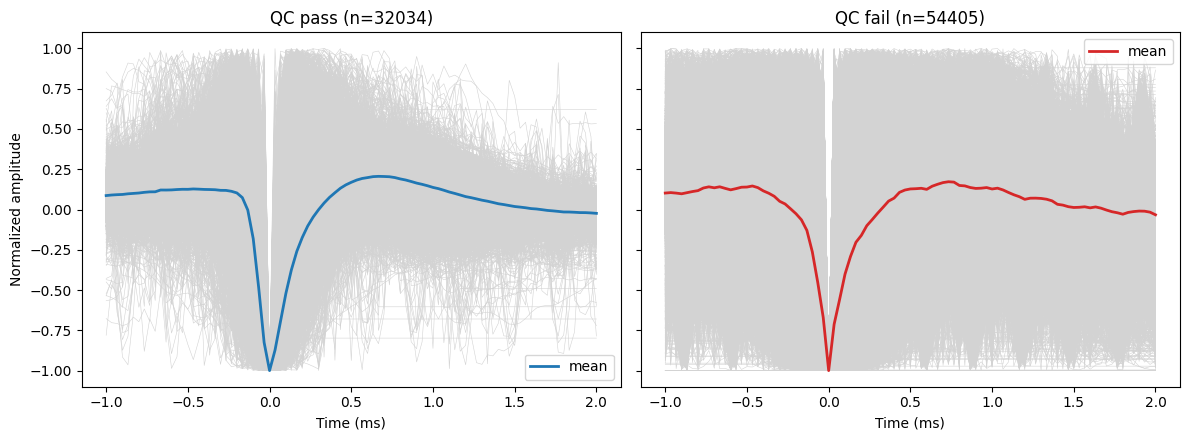

In [7]:
norm_waveforms = (
    np.vstack([normalize_waveform(w) for w in waveforms]) if len(waveforms) else waveforms
)
qc_pass = features["qc_pass"].astype(bool).values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, keep, title, color in (
    (axes[0], qc_pass, "QC pass", "C0"),
    (axes[1], ~qc_pass, "QC fail", "C3"),
):
    sub = norm_waveforms[keep]
    for w in sub:
        ax.plot(time_ms, w, color="lightgrey", linewidth=0.4)
    if len(sub):
        ax.plot(time_ms, sub.mean(axis=0), color=color, linewidth=2, label="mean")
    ax.set_title(f"{title} (n={int(keep.sum())})")
    ax.set_xlabel("Time (ms)")
    ax.legend()
axes[0].set_ylabel("Normalized amplitude")
plt.tight_layout()
plt.show()

### 4b. Choose the units to cluster

The morphology features are already in the reloaded table, so no recomputation
is needed. Here we cluster the **QC-passing** units (flip `USE_QC_ONLY` to use
all units).


Clustering 32034 units (USE_QC_ONLY=True).


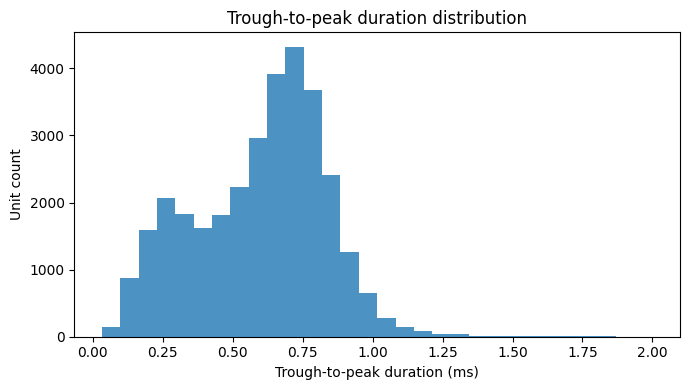

In [8]:
USE_QC_ONLY = True

if USE_QC_ONLY:
    mask = features["qc_pass"].astype(bool).values
else:
    mask = np.ones(len(features), dtype=bool)

feat = features.loc[mask].reset_index(drop=True).copy()
wf = norm_waveforms[mask]
print(f"Clustering {len(feat)} units (USE_QC_ONLY={USE_QC_ONLY}).")

# Distribution of the classic separator: trough-to-peak duration.
plt.figure(figsize=(7, 4))
plt.hist(feat["trough_to_peak_ms"], bins=30, color="C0", alpha=0.8)
plt.xlabel("Trough-to-peak duration (ms)")
plt.ylabel("Unit count")
plt.title("Trough-to-peak duration distribution")
plt.tight_layout()
plt.show()

### 4c. Standardize features and estimate the number of clusters

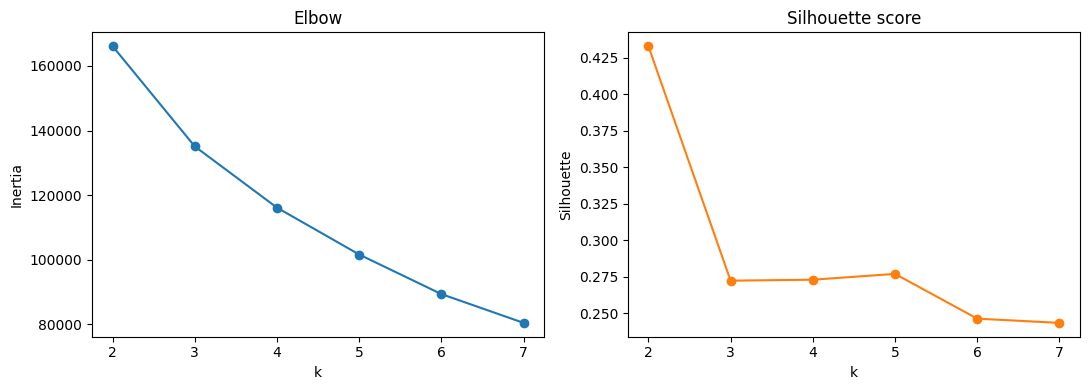

Best k by silhouette: 2


In [9]:
X_scaled, _ = scale_features(feat, feature_cols)
diag = estimate_n_clusters(X_scaled, k_range=range(2, 8), random_state=RANDOM_STATE)
ks, inertias, silhouettes, best_k = (
    diag["ks"], diag["inertias"], diag["silhouettes"], diag["best_k"]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow")
axes[1].plot(ks, silhouettes, "o-", color="C1")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette"); axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

print(f"Best k by silhouette: {best_k}")

### 4d. Cluster the units (KMeans + Gaussian Mixture)

In [10]:
N_CLUSTERS = max(2, best_k)  # override manually if desired

clustering = cluster_waveforms(
    feat, n_clusters=N_CLUSTERS, feature_cols=feature_cols, random_state=RANDOM_STATE
)
X_scaled = clustering["X_scaled"]

labels = feat["cluster_gmm"].values  # switch to 'cluster_kmeans' if preferred
print(f"KMeans cluster sizes: {np.bincount(feat['cluster_kmeans'].values)}")
print(f"GMM cluster sizes:    {np.bincount(feat['cluster_gmm'].values)}")

KMeans cluster sizes: [26841  5193]
GMM cluster sizes:    [25842  6192]


### 4e. Visualize the clusters

/tmp/ipykernel_75640/3095132682.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


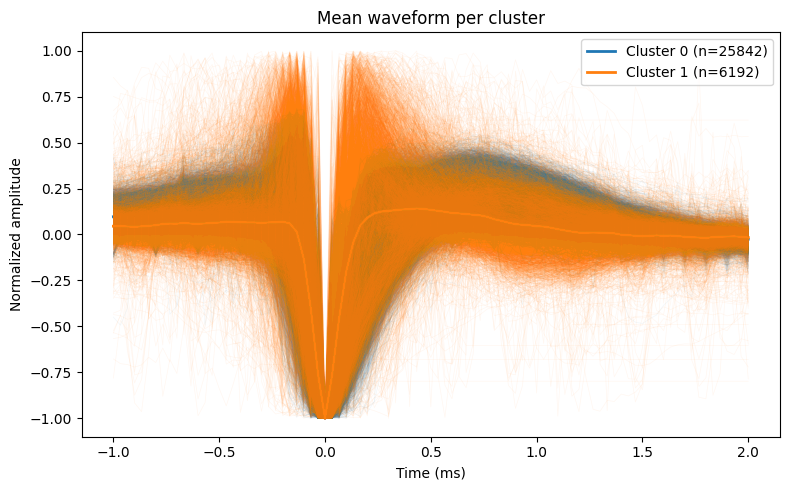

In [11]:
# Mean waveform per cluster
plt.figure(figsize=(8, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    plt.plot(time_ms, wf[m].mean(axis=0), linewidth=2, label=f"Cluster {c} (n={m.sum()})")
    for w in wf[m]:
        plt.plot(time_ms, w, color=f"C{c}", alpha=0.06, linewidth=0.5)
plt.xlabel("Time (ms)")
plt.ylabel("Normalized amplitude")
plt.title("Mean waveform per cluster")
plt.legend()
plt.tight_layout()
plt.show()

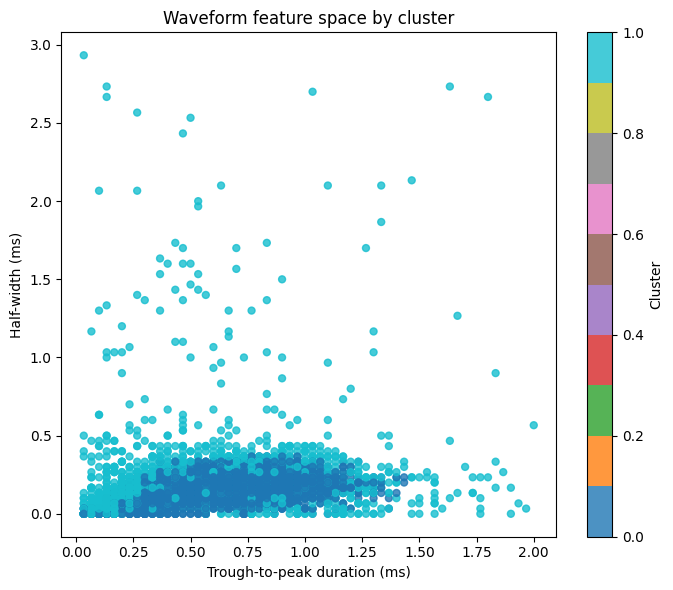

In [12]:
# Feature space: trough-to-peak vs half-width, colored by cluster
plt.figure(figsize=(7, 6))
sc = plt.scatter(feat["trough_to_peak_ms"], feat["half_width_ms"],
                 c=labels, cmap="tab10", s=25, alpha=0.8)
plt.xlabel("Trough-to-peak duration (ms)")
plt.ylabel("Half-width (ms)")
plt.title("Waveform feature space by cluster")
plt.colorbar(sc, label="Cluster")
plt.tight_layout()
plt.show()

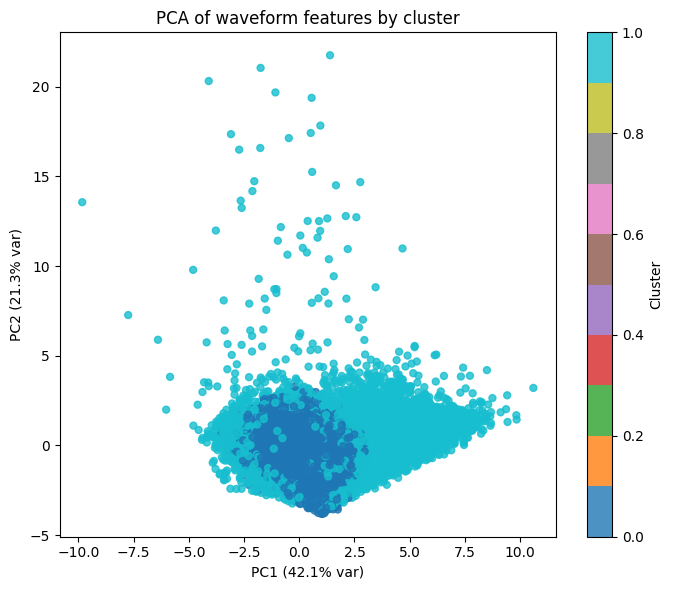

In [13]:
# PCA projection of the standardized feature space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of waveform features by cluster")
plt.colorbar(sc, label="Cluster")
plt.tight_layout()
plt.show()

In [14]:
# Cluster composition by brain region, and mean feature values per cluster
composition = pd.crosstab(feat["region"].fillna("None"), feat["cluster_kmeans"])
print("Cluster composition per region:")
print(composition, "\n")

summary = feat.groupby("cluster_kmeans")[feature_cols].mean()
summary["n_units"] = feat.groupby("cluster_kmeans").size()
summary

Cluster composition per region:
cluster_kmeans    0   1
region                 
AAA              62  28
ACAd5           213  30
ACAd6a            6   4
ACAv1             8   5
ACAv2/3          29  21
...             ...  ..
fiber tracts      5   1
fx                1   0
opt              13   1
root             39  12
void              3   2

[68 rows x 2 columns] 



,trough_to_peak_ms,half_width_ms,peak_trough_ratio,pre_peak_ratio,pre_peak_ms,repolarization_slope,recovery_slope,n_units
cluster_kmeans,,,,,,,,
0,0.658439,0.183345,0.284554,0.271577,0.343076,3.867443,-0.316860,26841
1,0.242699,0.105604,0.465341,0.103333,0.566249,9.941459,-1.558822,5193


## 5. Notes

- The big CSV round-trips the raw trough-aligned waveform via the `wf_###`
  columns, so `load_features_dataset` reconstructs both the features and the
  waveforms without touching the NWBs.
- `qc_pass` labels every unit, so you can cluster QC-passing units only, all
  units, or compare the two populations.
- Reusable helpers live in `waveform_clustering.py`
  (`build_features_dataset`, `save_dataset_csv`, `load_features_dataset`).
